In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!git clone https://github.com/huggingface/diffusers.git
%cd diffusers

!pip install -e .
!pip install accelerate transformers torchvision torch datasets pytorch-fid safetensors
!pip install bitsandbytes
!pip install clean-fid
!pip install xformers

Cloning into 'diffusers'...
remote: Enumerating objects: 121267, done.
remote: Counting objects: 100% (763/763), done.
remote: Compressing objects: 100% (421/421), done.
remote: Total 121267 (delta 615), reused 341 (delta 341), pack-reused 120504 (from 3)
Receiving objects: 100% (121267/121267), 94.46 MiB | 36.70 MiB/s, done.
Resolving deltas: 100% (90270/90270), done.
/content/diffusers
Obtaining file:///content/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 10.2 MB/s eta 0:00:00
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.39.0.dev0-0.editable-py3-none-any.whl size=11407 sha256=8c8f02789baea595ecacd53d6468f87b629b8df015e04e1be9fd19d0901f7978
  Stored in directory: /tmp/pip-ephem-wheel-cache-b

In [ ]:
from huggingface_hub import login
login()

In [4]:
BASE = "/content"

IMG_DIR = "/content/drive/MyDrive/Surrey_AML_CW/CelebA-HQ-img"
ATTR_PATH = "/content/drive/MyDrive/Surrey_AML_CW/CelebAMask-HQ-attribute-anno.txt"

TRAIN_DIR = "/content/data/train"
TEST_DIR  = "/content/data/test"

In [5]:
import os

IMG_DIR = "/content/drive/MyDrive/Surrey_AML_CW/CelebA-HQ-img"

print(f"Checking for images in: {IMG_DIR}")

if not os.path.isdir(IMG_DIR):
    raise ValueError(f"Directory does not exist: {IMG_DIR}")

# Load all images (case-insensitive, multiple formats)
all_imgs = [
    os.path.join(IMG_DIR, f)
    for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images found:", len(all_imgs))

if len(all_imgs) == 0:
    raise ValueError("No images found. Check extensions or folder structure.")


Checking for images in: /content/drive/MyDrive/Surrey_AML_CW/CelebA-HQ-img
Total images found: 30001


In [6]:
import os, random

IMG_DIR = "/content/drive/MyDrive/Surrey_AML_CW/CelebA-HQ-img"

all_imgs = [f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")]

random.seed(42)
random.shuffle(all_imgs)

n = len(all_imgs)

train_end = int(0.9 * n)   # 90% → ~27k

train_files = all_imgs[:train_end]
test_files  = all_imgs[train_end:]

print("Train:", len(train_files))
print("Test:", len(test_files))
print("Total:", len(train_files) + len(test_files))

Train: 27000
Test: 3001
Total: 30001


In [7]:
import os, shutil

TRAIN_DIR = "/content/data/train"
TEST_DIR  = "/content/data/test"

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

def clear(folder):
    for f in os.listdir(folder):
        os.remove(os.path.join(folder, f))

clear(TRAIN_DIR)
clear(TEST_DIR)

for f in train_files:
    shutil.copy(os.path.join(IMG_DIR, f), os.path.join(TRAIN_DIR, f))

for f in test_files:
    shutil.copy(os.path.join(IMG_DIR, f), os.path.join(TEST_DIR, f))

print("Train dir:", len(os.listdir(TRAIN_DIR)))
print("Test dir:", len(os.listdir(TEST_DIR)))

Train dir: 27000
Test dir: 3001


In [8]:
import os

print("Train exists:", os.path.exists("/content/data/train"))

if os.path.exists("/content/data/train"):
    print("Train count:", len(os.listdir("/content/data/train")))

print("Test exists:", os.path.exists("/content/data/test"))

if os.path.exists("/content/data/test"):
    print("Test count:", len(os.listdir("/content/data/test")))

Train exists: True
Train count: 27000
Test exists: True
Test count: 3001


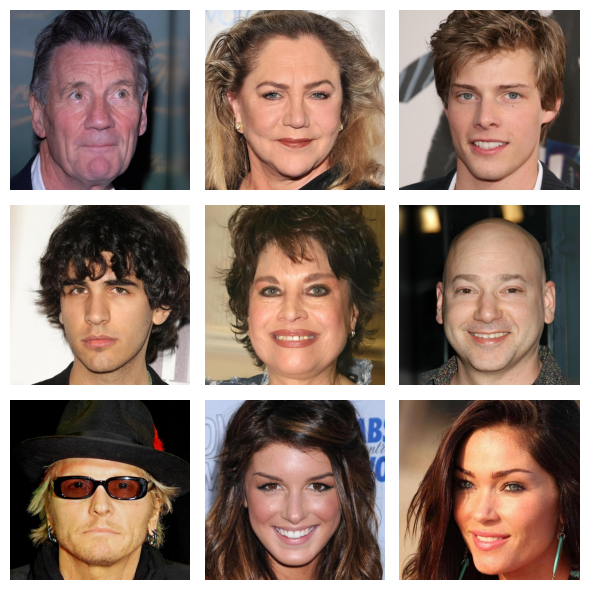

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(6,6))

for i in range(9):
    img = Image.open(os.path.join(TRAIN_DIR, train_files[i]))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

df = pd.read_csv(ATTR_PATH, sep=r"\s+", skiprows=1)
df = df.reset_index().rename(columns={"index": "image"})

def build_caption(row):
    attrs = []
    for col in df.columns[1:]:
        if row[col] == 1:
            attrs.append(col)
    return "a face with " + ", ".join(attrs)

df["text"] = df.apply(build_caption, axis=1)

# filter only train images
train_names = [f.split("/")[-1] for f in train_files]
df = df[df["image"].isin(train_names)]

df = df.rename(columns={"image": "file_name"})

df[["file_name", "text"]].to_csv("/content/data/train/metadata.csv", index=False)

print(df.head())

  file_name  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0     0.jpg                -1                1           1                1   
1     1.jpg                -1                1           1               -1   
4     4.jpg                -1               -1          -1               -1   
5     5.jpg                -1               -1           1               -1   
6     6.jpg                -1               -1           1                1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Smiling  Straight_Hair  \
0    -1     -1         1        -1          -1  ...        1             -1   
1    -1     -1        -1        -1          -1  ...        1             -1   
4    -1     -1         1        -1          -1  ...       -1              1   
5    -1     -1        -1        -1          -1  ...       -1             -1   
6    -1     -1        -1        -1          -1  ...       -1             -1   

   Wavy_Hair  Wearing_Earrings  Wearing_Hat  Weari

In [11]:
print(df.columns)

Index(['file_name', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'text'],
      dtype='object')


In [12]:
count = 0

for _, row in df.iterrows():
    img_name = row["file_name"]
    txt_name = img_name.replace(".jpg", ".txt")

    txt_path = os.path.join(TRAIN_DIR, txt_name)

    with open(txt_path, "w") as f:
        f.write(row["text"])

    count += 1

print("Caption files created:", count)

Caption files created: 26999


In [13]:
!ls /content/data/train | head

0.jpg
0.txt
10001.jpg
10001.txt
10002.jpg
10002.txt
10004.jpg
10004.txt
10005.jpg
10005.txt


In [14]:
!accelerate config default

accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml


In [15]:
%cd /content/diffusers/examples/text_to_image
!pwd

/content/diffusers/examples/text_to_image
/content/diffusers/examples/text_to_image


In [16]:
!accelerate launch train_text_to_image.py \
  --pretrained_model_name_or_path="CompVis/stable-diffusion-v1-4" \
  --train_data_dir="/content/data/train" \
  --resolution=512 \
  --center_crop \
  --random_flip \
  --train_batch_size=8 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=500 \
  --max_train_steps=25000 \
  --use_ema \
  --dataloader_num_workers=8 \
  --checkpointing_steps=5000 \
  --checkpoints_total_limit=3 \
  --output_dir="/content/sd14_celebahq" \
  --seed=42 \
  --mixed_precision="fp16" \
  --report_to="tensorboard" \
  --logging_dir="/content/sd14_celebahq/logs"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO:__main__:[RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
INFO:httpx:HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/CompVis/stable-diffusion-v1-4/133a

Available tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': ['train_loss'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


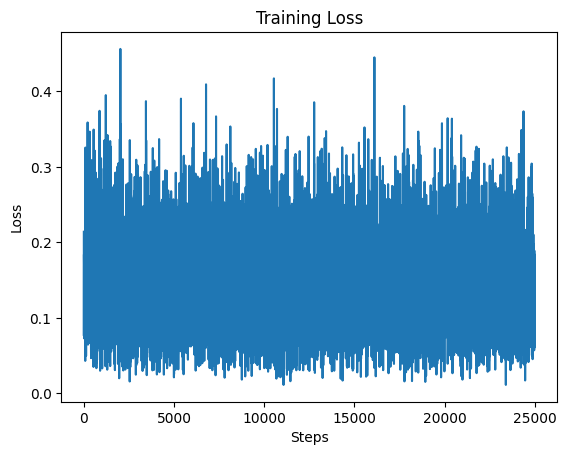

In [18]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

log_dir = "/content/sd14_celebahq/logs/text2image-fine-tune"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

print("Available tags:", ea.Tags())

# 👇 replace "loss" if needed based on output
loss_tag = "train_loss"

losses = [x.value for x in ea.Scalars(loss_tag)]
steps  = [x.step for x in ea.Scalars(loss_tag)]

plt.plot(steps, losses)
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

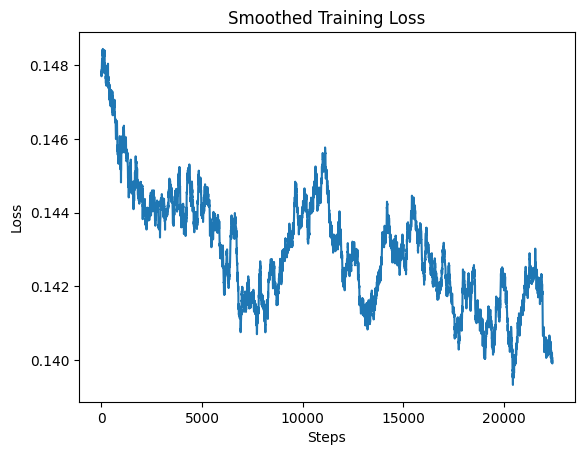

In [19]:
import numpy as np
import matplotlib.pyplot as plt

window = 1000  # smoothing window

smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')

plt.plot(steps[:len(smoothed)], smoothed)
plt.title("Smoothed Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

In [20]:
import numpy as np

loss_tag = "train_loss"
losses = [x.value for x in ea.Scalars(loss_tag)]

print("First 2k avg:", np.mean(losses[:2000]))
print("Last  2k avg:", np.mean(losses[-2000:]))

print("Std first:", np.std(losses[:2000]))
print("Std last :", np.std(losses[-2000:]))

First 2k avg: 0.14612534354906528
Last  2k avg: 0.14096245594508947
Std first: 0.06212885333658273
Std last : 0.05908736307638859


In [22]:
import shutil
from google.colab import files

MODEL_DIR = "/content/sd14_celebahq"
ZIP_PATH = "/content/final_sd14_model.zip"

# Remove checkpoints (keep only final weights)
import os
for item in os.listdir(MODEL_DIR):
    if item.startswith("checkpoint"):
        shutil.rmtree(os.path.join(MODEL_DIR, item))

# Zip the final model
shutil.make_archive("/content/final_sd14_model", 'zip', MODEL_DIR)

# Download
files.download(ZIP_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import pandas as pd

df = pd.read_csv(ATTR_PATH, sep=r"\s+", skiprows=1)

df = df.reset_index().rename(columns={"index": "image"})

def build_caption(row):

    attrs = []

    for col in df.columns[1:]:

        if row[col] == 1:

            attrs.append(col.replace("_", " "))

    return "a face with " + ", ".join(attrs)

df["text"] = df.apply(build_caption, axis=1)

# filter only test images
test_names = [f.split("/")[-1] for f in test_files]

df = df[df["image"].isin(test_names)]

df = df.rename(columns={"image": "file_name"})

df[["file_name", "text"]].to_csv(
    "/content/data/test/metadata.csv",
    index=False
)

print(df.head())

   file_name  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
2      2.jpg                -1               -1           1                1   
3      3.jpg                -1               -1           1               -1   
11    11.jpg                -1               -1           1               -1   
16    16.jpg                -1               -1           1               -1   
17    17.jpg                -1               -1          -1               -1   

    Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Smiling  Straight_Hair  \
2     -1     -1         1        -1          -1  ...        1             -1   
3     -1     -1        -1         1           1  ...        1             -1   
11    -1     -1         1        -1          -1  ...       -1             -1   
16    -1     -1         1        -1           1  ...       -1              1   
17    -1      1         1        -1          -1  ...       -1              1   

    Wavy_Hair  Wearing_Earrings  Weari

In [24]:
import pandas as pd
import random

TEST_META_PATH = "/content/data/test/metadata.csv"

df_test = pd.read_csv(TEST_META_PATH)

all_prompts = df_test["text"].dropna().tolist()

# Remove duplicates
all_prompts = list(set(all_prompts))

# Shuffle
random.seed(42)
random.shuffle(all_prompts)

PROMPTS = all_prompts[:300]

print("Total prompts loaded:", len(PROMPTS))

print("\nSample prompts:\n")

for p in PROMPTS[:10]:
    print("-", p)

Total prompts loaded: 300

Sample prompts:

- a face with 5 o Clock Shadow, Male, Mouth Slightly Open, No Beard, Young
- a face with 5 o Clock Shadow, Bags Under Eyes, Bangs, Big Nose, Brown Hair, Male, Pointy Nose, Sideburns, Straight Hair, Young
- a face with Arched Eyebrows, Attractive, Bangs, Big Lips, Black Hair, Heavy Makeup, High Cheekbones, Mouth Slightly Open, No Beard, Smiling, Straight Hair, Wearing Lipstick, Wearing Necklace, Young
- a face with Arched Eyebrows, Attractive, Big Lips, Blond Hair, Heavy Makeup, No Beard, Oval Face, Pale Skin, Pointy Nose, Straight Hair, Wearing Lipstick, Young
- a face with Attractive, Bags Under Eyes, Big Lips, Brown Hair, Heavy Makeup, High Cheekbones, Mouth Slightly Open, No Beard, Smiling, Wearing Lipstick, Young
- a face with Attractive, Black Hair, Bushy Eyebrows, Heavy Makeup, High Cheekbones, No Beard, Oval Face, Wearing Lipstick, Young
- a face with Bags Under Eyes, Big Nose, Brown Hair, Male, No Beard, Pointy Nose, Straight Hair
- a

In [25]:
%cd /content


/content


In [26]:
# --- Setup ---
import sys, os, torch
from tqdm.auto import tqdm

sys.path.append("/content/diffusers/src")

from diffusers import (
    StableDiffusionPipeline,
    DPMSolverMultistepScheduler
)

MODEL_PATH = "/content/sd14_celebahq"
GEN_DIR = "/content/generated_images"

os.makedirs(GEN_DIR, exist_ok=True)

# Clear old images
for f in os.listdir(GEN_DIR):
    os.remove(os.path.join(GEN_DIR, f))

# --- Load pipeline ---
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config
)

pipe.safety_checker = None
pipe.set_progress_bar_config(disable=False)

# --- Config ---
num_images = 300
batch_size = 4

idx = 0

pbar = tqdm(
    total=num_images,
    desc="Generating Images",
    unit="img"
)

while idx < num_images:

    cur_bs = min(batch_size, num_images - idx)

    prompts = [
        PROMPTS[(idx + j) % len(PROMPTS)]
        for j in range(cur_bs)
    ]

    generators = [
        torch.Generator(device="cuda").manual_seed(idx + j)
        for j in range(cur_bs)
    ]

    with torch.no_grad():

        outputs = pipe(
            prompt=prompts,
            height=512,
            width=512,
            num_inference_steps=50,
            guidance_scale=5.0,
            generator=generators
        )

    images = outputs.images

    for img in images:

        img.save(f"{GEN_DIR}/{idx:03d}.png")

        idx += 1
        pbar.update(1)

pbar.close()

print("Done.")
print("Generated:", len(os.listdir(GEN_DIR)))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Generating Images:   0%|          | 0/300 [00:00<?, ?img/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Done.
Generated: 300


In [30]:
import os

print("Generated:", len(os.listdir("/content/generated_images")))
print("Test:", len(os.listdir("/content/data/test")))

Generated: 300
Test: 3001


In [31]:
from PIL import Image
import os

def clean(folder):
    for f in os.listdir(folder):
        path = os.path.join(folder, f)
        try:
            Image.open(path).verify()
        except:
            os.remove(path)

clean("/content/data/test")
clean("/content/generated_images")


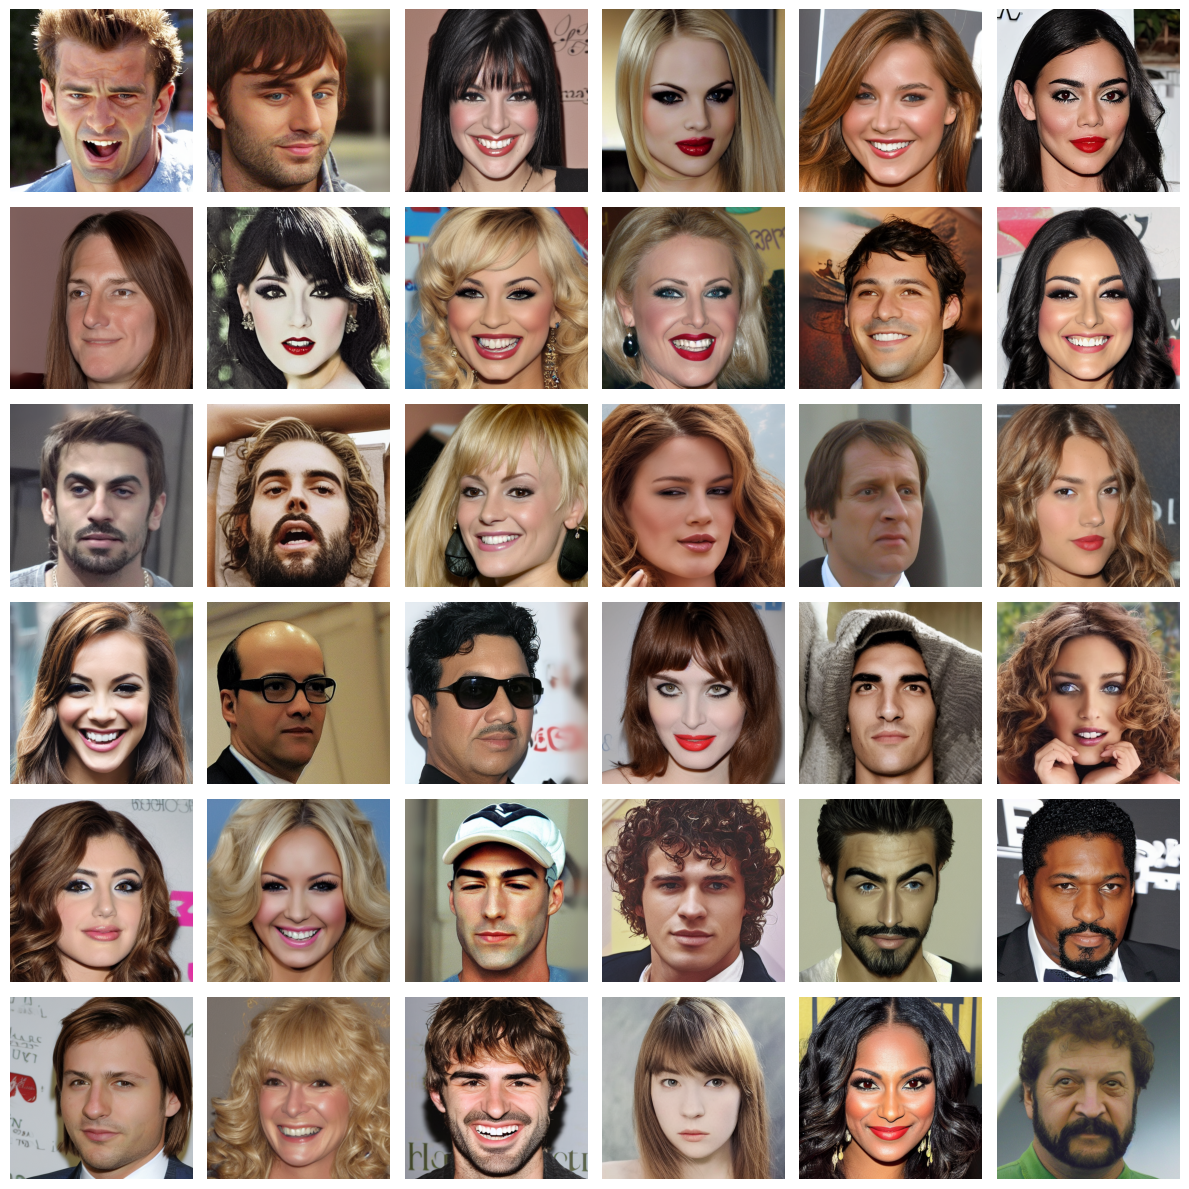

In [32]:
import matplotlib.pyplot as plt
from PIL import Image
import os

GEN_DIR = "/content/generated_images"

num_images = 36
cols = int(num_images**0.5)
rows = cols

sample_imgs = sorted(os.listdir(GEN_DIR))[:num_images]

plt.figure(figsize=(12,12))

for i, img_name in enumerate(sample_imgs):
    img = Image.open(os.path.join(GEN_DIR, img_name))
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

In [33]:

from PIL import Image
import os

def clean_resize(folder, size=(256,256)):
    for f in os.listdir(folder):
        path = os.path.join(folder, f)
        try:
            img = Image.open(path).convert("RGB").resize(size)
            img.save(path)
        except:
            os.remove(path)

clean_resize("/content/data/test")
clean_resize("/content/generated_images")


In [34]:
from pytorch_fid import fid_score

fid = fid_score.calculate_fid_given_paths(
    ["/content/data/test", "/content/generated_images"],
    batch_size=32,
    device="cuda",
    dims=2048
)

print("FID:", fid)

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 334MB/s]
100%|██████████| 10/10 [00:01<00:00,  7.16it/s]


FID: 74.23912111516916


In [35]:
import os

GEN_DIR = "/content/generated_images"

files = sorted(os.listdir(GEN_DIR))

for i, f in enumerate(files):
    old_path = os.path.join(GEN_DIR, f)
    new_path = os.path.join(GEN_DIR, f"{i:03d}.png")
    os.rename(old_path, new_path)

In [36]:
import shutil

shutil.make_archive("/content/generated_images", 'zip', GEN_DIR)

'/content/generated_images.zip'

In [37]:
from google.colab import files
files.download("/content/generated_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>